In [1]:
from pathlib import Path
import torch
import sys

import numpy as np

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.model import ConditionalUResNet

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


import matplotlib.pyplot as plt


plt.rcParams['text.usetex']=True
plt.style.use('classic')

In [2]:
data = torch.load(
    ROOT / "data" / "val.pt",
    weights_only=True
)

x = data["x"]
y_true = data["y"]

print("x:", x.shape)
print("y:", y_true.shape)


x: torch.Size([88, 2])
y: torch.Size([88, 192, 192, 3])


In [ ]:
model = ConditionalUResNet(
        in_channels=3,
        out_channels=3,
    ).to(DEVICE)

checkpoint = torch.load(
    ROOT / "checkpoints" / "best_model.pt",
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Loaded epoch:", checkpoint["epoch"] + 1)
print("Best validation loss:", checkpoint["val_loss"])

Loaded epoch: 1047
Best validation loss: 0.0652697855098681


In [ ]:
x_sample = x.to(DEVICE)

with torch.no_grad():
    prediction = model.predict(x_sample)

prediction = prediction.cpu().permute(0, 2, 3, 1)

np.save('./pred', prediction)
np.save('./param', data["x"])

print("Prediction shape:", prediction.shape)

Prediction shape: torch.Size([88, 192, 192, 3])


In [5]:
index = 0

pred = prediction[index]
true = y_true[index]

print("Pred:", pred.shape)
print("True:", true.shape)

Pred: torch.Size([192, 192, 3])
True: torch.Size([192, 192, 3])


In [6]:
image1 = true[:,:,2]
image2 = pred[:,:,2]

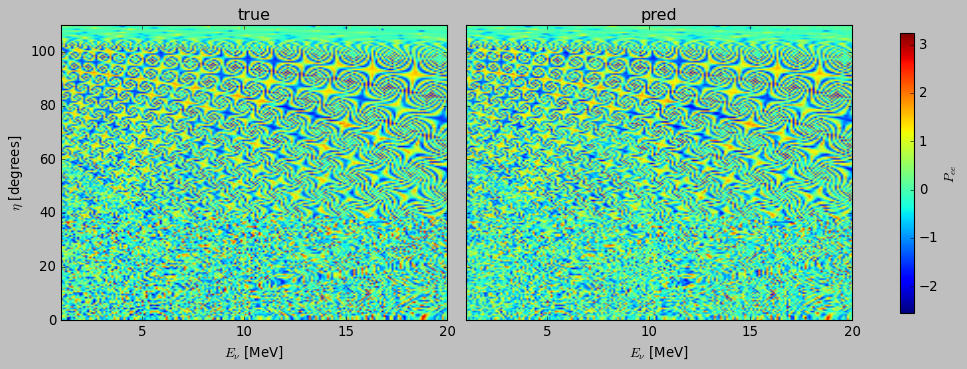

In [7]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# Use image1 range for BOTH panels
vmin = image1.min().item()
vmax = image1.max().item()

im1 = axes[0].imshow(
    image1.numpy(),
    origin='lower',
    extent=[1, 20, 0, 110],
    aspect='auto',
    vmin=vmin,
    vmax=vmax,
)

axes[0].set_xlabel(r'$E_\nu$ [MeV]')
axes[0].set_ylabel(r'$\eta$ [degrees]')
axes[0].set_title('true')

axes[1].imshow(
    image2.numpy(),
    origin='lower',
    extent=[1, 20, 0, 110],
    aspect='auto',
    vmin=vmin,
    vmax=vmax,
)

axes[1].set_xlabel(r'$E_\nu$ [MeV]')
axes[1].set_title('pred')

# One shared colorbar
fig.colorbar(
    im1,
    ax=axes,
    label=r'$P_{ee}$',
    shrink=0.95
)

plt.show()

In [ ]:
x_sample = torch.tensor([(2./10.) * (31. - 30) - 1.,
                         (2./3.) * (6. - 6.) - 1.]).reshape(1, 2).to(DEVICE)
print(x_sample.shape)

with torch.no_grad():
    prediction = model.predict(x_sample)

prediction = prediction.cpu().permute(0, 2, 3, 1)

np.save('./pred_single', prediction)

print("Prediction shape:", prediction.shape)

torch.Size([1, 2])
Prediction shape: torch.Size([1, 192, 192, 3])
